[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/openquantumhardware/qick/blob/merge-hrl-main/emulator/notebooks/00_intro_emu_2sg.ipynb)

# Example with 2 signal generator outputs


## 0. Colab Setup

Skip this cell if you're running locally with the `qick-venv` kernel (see [`emulator/README.md`](https://github.com/openquantumhardware/qick/blob/merge-hrl-main/emulator/README.md)) -- it's a no-op there. In Google Colab it clones this repo, builds Verilator 5.042 from source, and installs the Python dependencies. **First run takes a few minutes** (compiling Verilator); re-running later cells, or reconnecting to the same runtime, reuses what's already built.

In [1]:
import os
import sys
import pathlib
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def run(cmd, **kwargs):
    """Run a shell command, streaming output, and raise loudly on failure.

    Using this instead of bare `!command` / get_ipython().system() so a
    failure here stops the bootstrap immediately with a real traceback,
    instead of silently letting later cells fail with a confusing
    ModuleNotFoundError.
    """
    print(f"+ {cmd}")
    result = subprocess.run(cmd, shell=True, **kwargs)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (rc={result.returncode}): {cmd}")


if IN_COLAB:
    REPO_URL = "https://github.com/openquantumhardware/qick.git"
    REPO_BRANCH = "merge-hrl-main"
    REPO_DIR = pathlib.Path("/content/qick")

    if not REPO_DIR.exists():
        print(f"Cloning {REPO_URL} @ {REPO_BRANCH} ...")
        run(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    else:
        # Update in place instead of just reusing whatever was cloned
        # earlier in this runtime (e.g. from opening a previous notebook in
        # the same session) -- otherwise you silently keep running stale
        # code even though the repo has moved on. This is a bootstrap-only
        # clone, so discarding any local state here is safe.
        print(f"{REPO_DIR} already exists -- updating to the latest {REPO_BRANCH} ...")
        os.chdir(REPO_DIR)
        run(f"git fetch --depth 1 origin {REPO_BRANCH}")
        run("git reset --hard FETCH_HEAD")
    os.chdir(REPO_DIR)

    print("Fetching git submodules (Verilator source, AXI/common_cells) ...")
    run("git submodule update --init --recursive --depth 1")

    # Needed whether Verilator itself ends up prebuilt or compiled from
    # source: `make verilate` always invokes g++ (via ccache) to compile the
    # *generated* C++ model for each testbench build, every session. Gated
    # on `ccache` specifically (not pre-installed on a bare Colab image, and
    # the exact thing that broke without this) so that re-running this cell
    # -- or moving on to the next notebook in the same runtime -- doesn't
    # re-run apt every single time.
    import shutil
    if shutil.which("ccache") is None:
        print("Installing build/runtime dependencies (apt) ...")
        run("DEBIAN_FRONTEND=noninteractive apt-get -qq update")
        run(
            "DEBIAN_FRONTEND=noninteractive apt-get -qq install -y "
            "git help2man perl python3 make autoconf g++ flex bison ccache "
            "libgoogle-perftools-dev numactl perl-doc libfl-dev zlib1g-dev"
        )
    else:
        print("Build/runtime dependencies already installed, skipping apt.")

    def verilator_version():
        try:
            r = subprocess.run(["verilator", "--version"], capture_output=True, text=True)
        except FileNotFoundError:
            return ""
        return r.stdout

    if "5.042" not in verilator_version():
        # Fast path: a prebuilt Verilator 5.042, compiled on a real Colab
        # runtime and hosted as a GitHub Release asset -- avoids a ~10-15
        # minute source compile on every session. Falls back to building
        # from source if the download/extraction doesn't work out (e.g. the
        # asset is gone, or a future Colab image isn't binary-compatible).
        PREBUILT_URL = (
            "https://github.com/openquantumhardware/qick/releases/download/"
            "verilator-5.042-colab/verilator-5.042-colab-x86_64.tar.gz"
        )
        prebuilt_ok = False
        print("Trying prebuilt Verilator 5.042 (fast path) ...")
        try:
            run(f"curl -fL -o /tmp/verilator-prebuilt.tar.gz {PREBUILT_URL}")
            run("tar -C /usr/local -xzf /tmp/verilator-prebuilt.tar.gz")
            prebuilt_ok = "5.042" in verilator_version()
        except RuntimeError as e:
            print(f"Prebuilt Verilator download/install failed ({e}); building from source instead.")

        if prebuilt_ok:
            print("Prebuilt Verilator 5.042 installed.")
        else:
            print("Building Verilator 5.042 from source (a few minutes, first run only) ...")
            os.chdir(REPO_DIR / "emulator" / "submodules" / "verilator")
            run("autoconf")
            run("./configure")
            run("make -j$(nproc)")
            run("make install")
            os.chdir(REPO_DIR)
            final_version = verilator_version()
            if "5.042" not in final_version:
                raise RuntimeError(
                    "Verilator build finished but 'verilator --version' still doesn't "
                    f"report 5.042 (got: {final_version!r})"
                )
            print(final_version)
    else:
        print("Verilator 5.042 already installed, skipping build.")

    # Scientific-Python deps only -- NOT jupyter/ipykernel, which would fight
    # with Colab's own kernel runtime. `emulator/requirements.txt` is for the
    # local venv+Jupyter setup (see emulator/README.md); Colab needs a subset.
    print("Installing Python dependencies ...")
    run("pip install numpy scipy matplotlib tqdm")
    run("pip install -e .")

    # Belt-and-suspenders: insert the source dirs directly, so `import qick`
    # works below even if pip's editable-install .pth file isn't picked up by
    # this already-running interpreter (a known Colab quirk).
    for rel in ("qick_lib", "emulator/software"):
        p = str(REPO_DIR / rel)
        if p not in sys.path:
            sys.path.insert(0, p)

    os.chdir(REPO_DIR / "emulator" / "notebooks")

    # Verify right here, in this cell, instead of letting a failure surface
    # one cell later as a confusing ModuleNotFoundError.
    import importlib
    importlib.invalidate_caches()
    try:
        import qick
        print(f"\nColab setup complete. qick {qick.get_version()} importable from {qick.__file__}")
    except ImportError as e:
        raise RuntimeError(
            f"Setup finished but 'import qick' still fails ({e}). "
            f"cwd={pathlib.Path.cwd()}, REPO_DIR contents: {list(REPO_DIR.iterdir())}"
        ) from e
    print(f"Working directory: {pathlib.Path.cwd()}")
else:
    print("Not running in Colab -- skipping clone/build (using the local checkout as-is).")


Not running in Colab -- skipping clone/build (using the local checkout as-is).


## Setup

In [2]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local Qick path setup
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
sys.path.insert(0,str(REPO_ROOT / '..' / 'qick_lib/'))
# Local QickEmu path setup
source_dir = REPO_ROOT / 'software'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))
# Display current sys.path
print(sys.path)


import qick_emu
importlib.reload(qick_emu)          # pick up edits without kernel restart
from qick_emu import QickEmu

from qick.asm_v2 import AveragerProgramV2, QickSpan, QickSweep1D

# emulator init
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# artifact root
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '00_intro'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)


print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

# Default Path is the artifacts root.
OUT = ARTIFACTS_ROOT

## QICKEmu Auxiliary Functions
def QICKEmu_plot_dac(soc_emu, OUT):
    # DAC waveform
    t_dac_ch0, dac_ch0 = soc_emu.load_dac(OUT, absolute_time=True)
    t_dac_ch1, dac_ch1 = soc_emu.load_dac(emu_dir=OUT, gen_ch=1, absolute_time=True)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac_ch0, dac_ch0, linewidth=0.8)
    plt.plot(t_dac_ch1, dac_ch1, linewidth=0.8)
    plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()


QICK library version mismatch: 0.2.366 remote (the board), 0.2.88 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


['/home/larnaldi/git/emu_v1.2.0/emulator/software', '/home/larnaldi/git/emu_v1.2.0/emulator/../qick_lib', '/home/larnaldi/tools/2025.2/Vitis/functional_suite/vfs/python', '/home/larnaldi/tools/2025.2/Vitis/functional_suite/varray/python', '/home/larnaldi/tools/2025.2/Vitis/functional_suite/lib/python', '/home/larnaldi/tools/2025.2/Vitis/functional_suite/hil/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/larnaldi/git/emu_v1.2.0/.venv/lib/python3.12/site-packages', '/home/larnaldi/git/emu_v1.2.0/qick_lib']
REPO_ROOT     : /home/larnaldi/git/emu_v1.2.0/emulator
ARTIFACTS_ROOT: /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/00_intro
QICK running on QICKEmu, software version 0.2.366

Firmware configuration (built Fri Sep 4 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	3 signal genera

In [3]:
# QICKEmu channel assignments
GEN_CH0   = 0
GEN_CH1   = 1
RO_CH     = 0
TRIG_TIME = 0.40   # us
FREQ      = 100    # MHz


## Basic multi-pulse program

Port of `00_intro.ipynb` cell 10. Five pulses of different styles back-to-back
through a single RO window.

In [4]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch0 = cfg['gen_ch0']
        gen_ch1 = cfg['gen_ch1']

        self.declare_gen(ch=gen_ch0, nqz=1)
        self.declare_gen(ch=gen_ch1, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.2
        self.add_gauss(ch=gen_ch0, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)

        self.add_pulse(ch=gen_ch0, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch0, name='mygaus', ro_ch=ro_ch,
                       style='arb', envelope='ramp',
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch0, name='myconst', ro_ch=ro_ch,
                       style='const', length=0.2,
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch0, name='myflattop2', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=90, gain=1.0)


        self.add_gauss(ch=gen_ch1, name='ramp_ch1',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)

        self.add_pulse(ch=gen_ch1, name='myconst_ch1', ro_ch=ro_ch,
                       style='const', length=0.5,
                       freq=cfg['freq']*2, phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch1, name='mygauss_ch1', ro_ch=ro_ch,
                       style='arb', envelope='ramp_ch1',
                       freq=cfg['freq']*2, phase=0, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch0)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        # NB: `ddr4=True` is a no-op in the emulator — kept so the program
        # matches the on-hardware version byte-for-byte.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch0'], name='myflattop',  t=0)
        self.pulse(ch=cfg['gen_ch0'], name='mygaus',     t=0.4)
        self.pulse(ch=cfg['gen_ch0'], name='myconst',    t=0.8)
        self.pulse(ch=cfg['gen_ch0'], name='myflattop2', t=1.2)
        self.pulse(ch=cfg['gen_ch0'], name='mygaus',     t=1.6)

        self.pulse(ch=cfg['gen_ch1'], name='myconst_ch1', t=0.5)
        self.pulse(ch=cfg['gen_ch1'], name='mygauss_ch1', t=1.5)

config = {
    'gen_ch0':   GEN_CH0,
    'gen_ch1':   GEN_CH1,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    1.9,
}

prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)


### Simulate & plot (MultiPulse)

Artifacts -> /home/larnaldi/git/emu_v1.2.0/emulator/artifacts/00_intro/multi_pulse_2sg
[sim] Running simulation with EMU_DIR=../artifacts/00_intro/multi_pulse_2sg ...


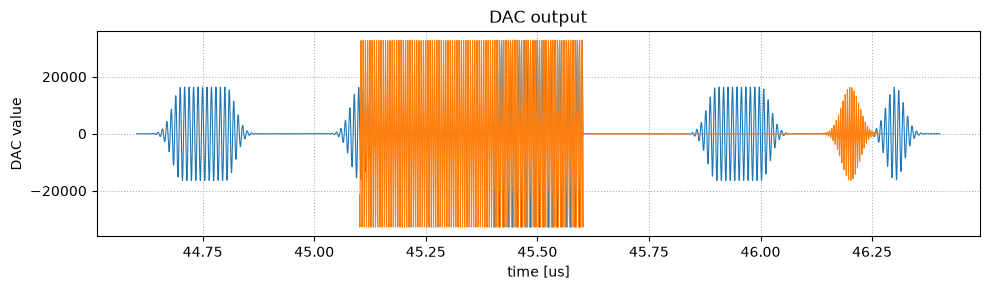

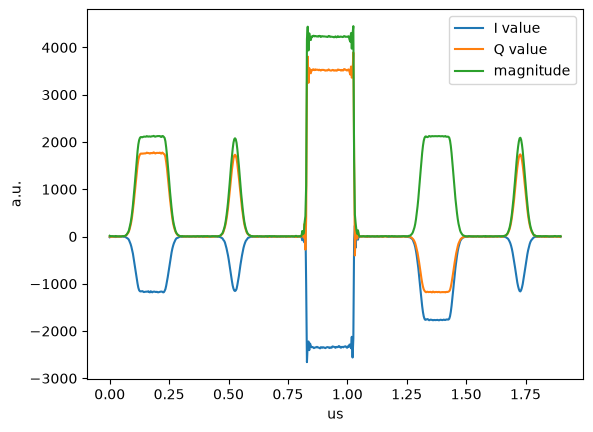

In [5]:
# emulator artifacts
OUT = ARTIFACTS_ROOT / 'multi_pulse_2sg'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {OUT}')
soc = soc.prepare_emu(memdir=OUT, build=True, trace=False, verbose=False)

# PERFORMANCE NOTE: build=True runs `make verilate`, a full re-parse and
# recompile of the Verilog testbench -- the slowest part of an emulator run.
# This notebook only acquires once, so it's harmless here, but if you add
# more prog.acquire()/acquire_decimated() cells below, pass build=False on
# every later prepare_emu() call (or set soc._default_build = False) to
# reuse the compiled binary instead of rebuilding it every time -- see
# 00_intro_emu.ipynb for the full pattern.

## Run the emulator acquire path, which will generate the CSV output files
iq_list = prog.acquire_decimated(soc)

## Plot DAC waveform
QICKEmu_plot_dac(soc, OUT)

# Decimated I/Q -- mirror of cell 10 in 00_intro.ipynb
t       = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

In [6]:
# print the program (ugly!)
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	ConfigReadout(ch=0, name='myro', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x79da00594890>}, t_regs={'t': 0})
	Delay(t=1.0, auto=True, gens=True, ros=True, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x79d98688ac00>}, t_regs={'t': 430})
	OpenLoop(n=1, name='reps')
	Trigger(ros=[0], tts=[], pins=[0], t=0.4, width=0.023251488095238096, ddr4=True, mr=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x79d986889580>, 'width': <qick.asm_v2.QickParam object at 0x79d9868929f0>}, t_regs={'t': 172, 'width': 10}, outdict=defaultdict(<class 'int'>, {}), trigset={0, 10})
	Pulse(ch=0, name='myflattop', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x79d986892a20>}, t_regs={'t': 0})
	Pulse(ch=0, name='mygaus', t=0.4, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x79d986891910>}, t_regs={'t': 172})
	Pulse(ch=0, name='myconst', t=0.8, tag=None, t_params={'t': <qick.asm_v2.QickPara